# Bellabeat Case Study
## Google Data Analytics Certificate — Case Study 2
### How Can a Wellness Company Play It Smart?

**Analyst:** *Fahim Akbar*  
**Date:** *March 10, 2026*  
**Tools:** Python, pandas, matplotlib, seaborn  
**Dataset:** [FitBit Fitness Tracker Data](https://www.kaggle.com/datasets/arashnic/fitbit) (CC0 Public Domain, via Kaggle/Möbius)

---

## Overview

In this case study, I act as a junior data analyst on the marketing team at **Bellabeat**, a high-tech manufacturer of health-focused products for women. I will analyze FitBit smart device data to uncover trends in how users engage with their devices, then apply those insights to make marketing recommendations for Bellabeat's **Leaf tracker**.

The analysis follows the six-phase data analysis process:
1. **Ask** — Define the business task
2. **Prepare** — Understand the data
3. **Process** — Clean and transform the data
4. **Analyze** — Identify trends and relationships
5. **Share** — Visualize findings
6. **Act** — Make recommendations


### Business Task

Bellabeat wants to grow its share of the global smart device market. To do that, leadership has asked the analytics team to:

- Analyze how consumers use **non-Bellabeat** smart devices
- Identify behavioral trends in activity, sleep, and engagement
- Apply those trends to a Bellabeat product to guide marketing strategy

**Key Questions:**
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat's marketing strategy?

**Stakeholders:** Urška Sršen (CCO & Co-founder), Sando Mur (Co-founder), Bellabeat Marketing Analytics Team  
**Focus Product:** Bellabeat Leaf (wearable wellness tracker)


### Data Source

The dataset used is the **FitBit Fitness Tracker Dataset**, publicly available on Kaggle under a CC0 (Public Domain) license. It was collected via a survey of 30 eligible Fitbit users over a 31-day period in 2016.

**Files used in this analysis:**
| File | Description |
|---|---|
| `dailyActivity_merged.csv` | Daily steps, distance, active minutes, calories |
| `sleepDay_merged.csv` | Total minutes asleep and time in bed per night |
| `hourlySteps_merged.csv` | Step counts broken down by hour |
| `hourlyCalories_merged.csv` | Calories burned broken down by hour |

### Data Credibility (ROCCC Check)
- **Reliable:** Small sample (33 users) — limited reliability
- **Original:** Third-party data collected via Amazon Mechanical Turk
- **Comprehensive:** Covers activity, sleep, and calories but lacks demographics
- **Current:** Collected in 2016 — may not reflect current behavior
- **Cited:** CC0 license, publicly available

### Limitations
- Only 33 users — not statistically representative
- No gender, age, or demographic information
- Sleep data only available for 24 of the 33 users
- Data is from 2016; smart device usage has evolved significantly since

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load all four datasets
daily = pd.read_csv('dailyActivity_merged.csv')
sleep = pd.read_csv('sleepDay_merged.csv')
hourly_steps = pd.read_csv('hourlySteps_merged.csv')
hourly_cal = pd.read_csv('hourlyCalories_merged.csv')

print("Datasets loaded:")
print(f"  dailyActivity:  {daily.shape}")
print(f"  sleepDay:       {sleep.shape}")
print(f"  hourlySteps:    {hourly_steps.shape}")
print(f"  hourlyCalories: {hourly_cal.shape}")

Datasets loaded:
  dailyActivity:  (457, 15)
  sleepDay:       (413, 5)
  hourlySteps:    (24084, 3)
  hourlyCalories: (24084, 3)


In [4]:
# Preview the datasets
print("=== Daily Activity (first 3 rows) ===")
print(daily.head(3).to_string())

print("\n=== Sleep Data (first 3 rows) ===")
print(sleep.head(3).to_string())

print("\n=== Hourly Steps (first 3 rows) ===")
print(hourly_steps.head(3).to_string())

=== Daily Activity (first 3 rows) ===
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  FairlyActiveMinutes  LightlyActiveMinutes  SedentaryMinutes  Calories
0  1503960366    3/25/2016       11004           7.11             7.11                       0.0                2.57                      0.46                 4.07                      0.0                 33                   12                   205               804      1819
1  1503960366    3/26/2016       17609          11.55            11.55                       0.0                6.92                      0.73                 3.91                      0.0                 89                   17                   274               588      2154
2  1503960366    3/27/2016       12736           8.53             8.53                       0.0                4.66         

In [5]:
# Check for missing values and data types
print("=== Daily Activity — Info ===")
print(daily.info())

print("\n=== Sleep — Info ===")
print(sleep.info())

print("\nNull counts:")
print("  daily:", daily.isnull().sum().sum())
print("  sleep:", sleep.isnull().sum().sum())
print("  hourly_steps:", hourly_steps.isnull().sum().sum())
print("  hourly_cal:", hourly_cal.isnull().sum().sum())

=== Daily Activity — Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-n

In [6]:
# Convert date/time columns from strings to datetime objects
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])
hourly_cal['ActivityHour'] = pd.to_datetime(hourly_cal['ActivityHour'])

print("Date columns parsed successfully.")

Date columns parsed successfully.


In [7]:
# Check for and remove duplicates
print("Duplicates found:")
print(f"  daily: {daily.duplicated().sum()}")
print(f"  sleep: {sleep.duplicated().sum()}")
print(f"  hourly_steps: {hourly_steps.duplicated().sum()}")

# Remove duplicates from sleep dataset
sleep = sleep.drop_duplicates()
print(f"\nSleep dataset after removing duplicates: {sleep.shape}")

Duplicates found:
  daily: 0
  sleep: 3
  hourly_steps: 0

Sleep dataset after removing duplicates: (410, 5)


In [8]:
# Add useful columns for analysis

# Day of week from date
daily['DayOfWeek'] = daily['ActivityDate'].dt.day_name()

# Hour of day from datetime
hourly_steps['Hour'] = hourly_steps['ActivityHour'].dt.hour
hourly_cal['Hour'] = hourly_cal['ActivityHour'].dt.hour

# Sleep hours (convert from minutes)
sleep['SleepHours'] = sleep['TotalMinutesAsleep'] / 60

# Minutes awake in bed (tossing and turning)
sleep['MinutesAwakeInBed'] = sleep['TotalTimeInBed'] - sleep['TotalMinutesAsleep']

# Activity level based on step count (standard health guidelines)
def classify_activity(steps):
    if steps < 5000:
        return 'Sedentary'
    elif steps < 7500:
        return 'Low Active'
    elif steps < 10000:
        return 'Somewhat Active'
    else:
        return 'Active'

daily['ActivityLevel'] = daily['TotalSteps'].apply(classify_activity)

print("Derived columns created successfully.")
print(daily[['ActivityDate', 'DayOfWeek', 'TotalSteps', 'ActivityLevel']].head())

Derived columns created successfully.
  ActivityDate DayOfWeek  TotalSteps ActivityLevel
0   2016-03-25    Friday       11004        Active
1   2016-03-26  Saturday       17609        Active
2   2016-03-27    Sunday       12736        Active
3   2016-03-28    Monday       13231        Active
4   2016-03-29   Tuesday       12041        Active


In [9]:
# Overall summary statistics
print("=== Daily Activity Summary ===")
print(daily[['TotalSteps', 'Calories', 'SedentaryMinutes', 'VeryActiveMinutes']].describe().round(2))

print("\n=== Sleep Summary ===")
print(sleep[['SleepHours', 'MinutesAwakeInBed']].describe().round(2))

print(f"\nUnique users in daily data: {daily['Id'].nunique()}")
print(f"Unique users in sleep data:  {sleep['Id'].nunique()}")

=== Daily Activity Summary ===
       TotalSteps  Calories  SedentaryMinutes  VeryActiveMinutes
count      457.00    457.00            457.00             457.00
mean      6546.56   2189.45            995.28              16.62
std       5398.49    815.48            337.02              28.92
min          0.00      0.00             32.00               0.00
25%       1988.00   1776.00            728.00               0.00
50%       5986.00   2062.00           1057.00               0.00
75%      10198.00   2667.00           1285.00              25.00
max      28497.00   4562.00           1440.00             202.00

=== Sleep Summary ===
       SleepHours  MinutesAwakeInBed
count      410.00             410.00
mean         6.99              39.31
std          1.98              46.71
min          0.97               0.00
25%          6.02              17.00
50%          7.21              25.50
75%          8.17              40.00
max         13.27             371.00

Unique users in daily data:

In [10]:
# How are users distributed across activity levels?
activity_order = ['Sedentary', 'Low Active', 'Somewhat Active', 'Active']
activity_counts = daily['ActivityLevel'].value_counts().reindex(activity_order)
activity_pct = (activity_counts / activity_counts.sum() * 100).round(1)

print("Activity Level Distribution:")
for level, count, pct in zip(activity_counts.index, activity_counts.values, activity_pct.values):
    print(f"  {level:<20} {count:>4} days  ({pct}%)")

print(f"\nAverage daily steps: {daily['TotalSteps'].mean():.0f}")
print(f"10,000-step goal met: {(daily['TotalSteps'] >= 10000).mean()*100:.1f}% of days")

Activity Level Distribution:
  Sedentary             197 days  (43.1%)
  Low Active             83 days  (18.2%)
  Somewhat Active        50 days  (10.9%)
  Active                127 days  (27.8%)

Average daily steps: 6547
10,000-step goal met: 27.8% of days


In [11]:
# Which days are users most and least active?
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = daily.groupby('DayOfWeek')[['TotalSteps', 'Calories', 'SedentaryMinutes']].mean().reindex(dow_order).round(1)

print("Average Steps, Calories, and Sedentary Minutes by Day of Week:")
print(dow_stats.to_string())

Average Steps, Calories, and Sedentary Minutes by Day of Week:
           TotalSteps  Calories  SedentaryMinutes
DayOfWeek                                        
Monday         7118.6    2252.9            1032.9
Tuesday        4914.9    1742.4             850.2
Wednesday      7510.7    2377.5            1011.1
Thursday       6847.1    2297.8            1055.1
Friday         6737.6    2313.5            1054.7
Saturday       7089.8    2277.6             976.6
Sunday         6058.0    2167.6            1015.7


In [12]:
# When during the day are users most active?
hourly_avg = hourly_steps.groupby('Hour')['StepTotal'].mean().round(1)

print("Average Steps by Hour of Day:")
for hour, steps in hourly_avg.items():
    bar = '█' * int(steps / 30)
    print(f"  {hour:02d}:00  {bar}  ({steps:.0f})")

Average Steps by Hour of Day:
  00:00  █  (44)
  01:00    (20)
  02:00    (11)
  03:00    (7)
  04:00    (10)
  05:00    (26)
  06:00  ████  (120)
  07:00  ████████  (267)
  08:00  ████████████  (366)
  09:00  ██████████████  (430)
  10:00  ██████████████  (437)
  11:00  ███████████████  (453)
  12:00  █████████████████  (521)
  13:00  ███████████████  (458)
  14:00  ███████████████  (474)
  15:00  █████████████  (390)
  16:00  ██████████████  (447)
  17:00  ███████████████  (454)
  18:00  ████████████████  (506)
  19:00  █████████████████  (529)
  20:00  █████████████  (399)
  21:00  ████████  (261)
  22:00  █████  (173)
  23:00  ███  (103)


In [13]:
# How much sleep are users getting?
avg_sleep = sleep['SleepHours'].mean()
pct_under_7 = (sleep['SleepHours'] < 7).mean() * 100
avg_awake = sleep['MinutesAwakeInBed'].mean()

print(f"Average sleep per night:        {avg_sleep:.2f} hours")
print(f"% of nights below 7 hours:      {pct_under_7:.1f}%")
print(f"Avg minutes awake in bed:       {avg_awake:.1f} minutes")
print(f"\nCDC recommended minimum: 7 hours")
print(f"Average is {'below' if avg_sleep < 7 else 'above'} the minimum by {abs(avg_sleep - 7)*60:.0f} minutes")

Average sleep per night:        6.99 hours
% of nights below 7 hours:      44.1%
Avg minutes awake in bed:       39.3 minutes

CDC recommended minimum: 7 hours
Average is below the minimum by 1 minutes


In [14]:
# How sedentary are users on average?
avg_sed_hrs = daily['SedentaryMinutes'].mean() / 60
pct_over_8h = (daily['SedentaryMinutes'] > 480).mean() * 100

print(f"Average sedentary hours per day:        {avg_sed_hrs:.1f} hours")
print(f"% of days with >8 hrs sedentary:        {pct_over_8h:.1f}%")
print(f"\nSteps-to-Calories correlation:          {daily['TotalSteps'].corr(daily['Calories']):.3f}")

Average sedentary hours per day:        16.6 hours
% of days with >8 hrs sedentary:        94.3%

Steps-to-Calories correlation:          0.581


In [15]:
# How consistently are users tracking their data?
engagement = daily.groupby('Id')['ActivityDate'].count().reset_index()
engagement.columns = ['Id', 'DaysTracked']

print("Days Tracked per User:")
print(engagement['DaysTracked'].describe().round(1))
print(f"\nHigh engagement (25+ days): {(engagement['DaysTracked'] >= 25).sum()} users")
print(f"Low engagement  (<=15 days): {(engagement['DaysTracked'] <= 15).sum()} users")

Days Tracked per User:
count    35.0
mean     13.1
std       5.4
min       8.0
25%      10.5
50%      12.0
75%      12.0
max      32.0
Name: DaysTracked, dtype: float64

High engagement (25+ days): 2 users
Low engagement  (<=15 days): 31 users


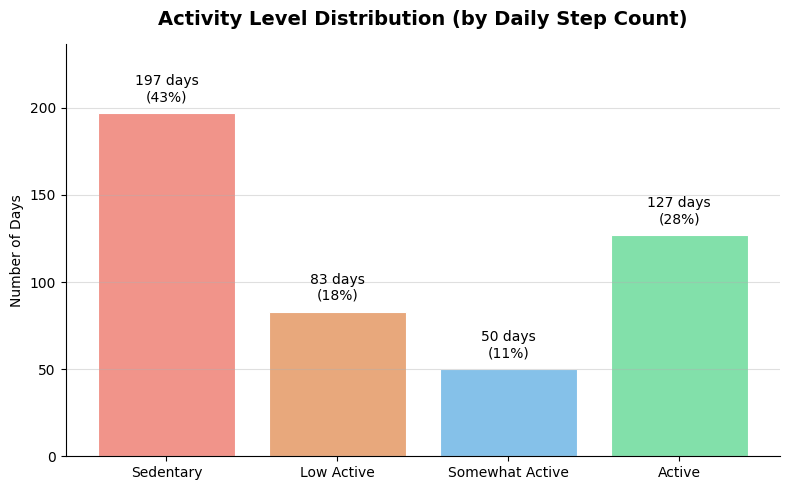

Chart 1 saved.


In [16]:
#Activity Level Distribution (by Daily Step Count)
fig, ax = plt.subplots(figsize=(8, 5))

activity_order = ['Sedentary', 'Low Active', 'Somewhat Active', 'Active']
activity_counts = daily['ActivityLevel'].value_counts().reindex(activity_order)
colors = ['#F1948A', '#E8A87C', '#85C1E9', '#82E0AA']

bars = ax.bar(activity_counts.index, activity_counts.values, color=colors, edgecolor='white', linewidth=0.8)

# Add value labels on bars
for bar in bars:
    pct = bar.get_height() / activity_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{int(bar.get_height())} days\n({pct:.0f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Activity Level Distribution (by Daily Step Count)', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Number of Days')
ax.set_ylim(0, activity_counts.max() * 1.2)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_activity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

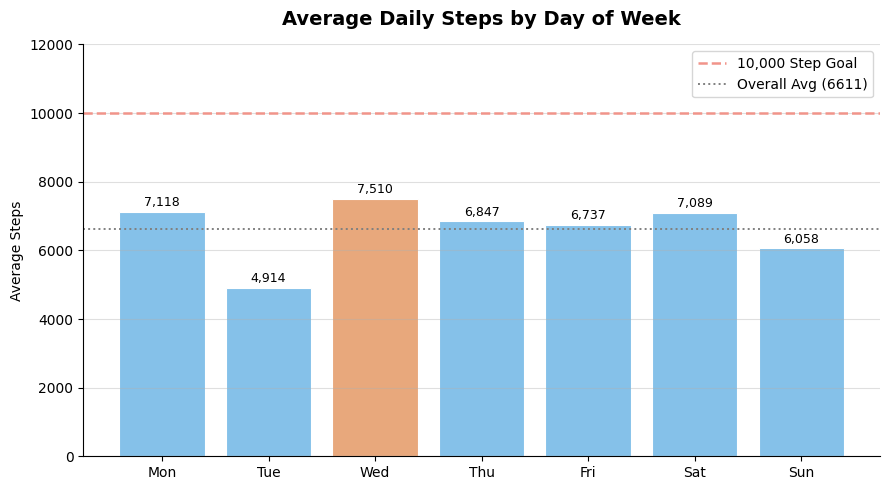

Chart 2 saved.


In [17]:
#Average Daily Steps by Day of Week
fig, ax = plt.subplots(figsize=(9, 5))

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
days_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_steps = daily.groupby('DayOfWeek')['TotalSteps'].mean().reindex(dow_order)

bar_colors = ['#85C1E9' if v < dow_steps.max() else '#E8A87C' for v in dow_steps]

bars = ax.bar(days_short, dow_steps, color=bar_colors, edgecolor='white', linewidth=0.8)

# 10,000 step goal line
ax.axhline(10000, color='#F1948A', linestyle='--', linewidth=1.8, label='10,000 Step Goal')
# Average line
ax.axhline(dow_steps.mean(), color='gray', linestyle=':', linewidth=1.4, label=f'Overall Avg ({dow_steps.mean():.0f})')

# Labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 12000)
ax.set_title('Average Daily Steps by Day of Week', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Average Steps')
ax.legend()
ax.grid(axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_steps_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

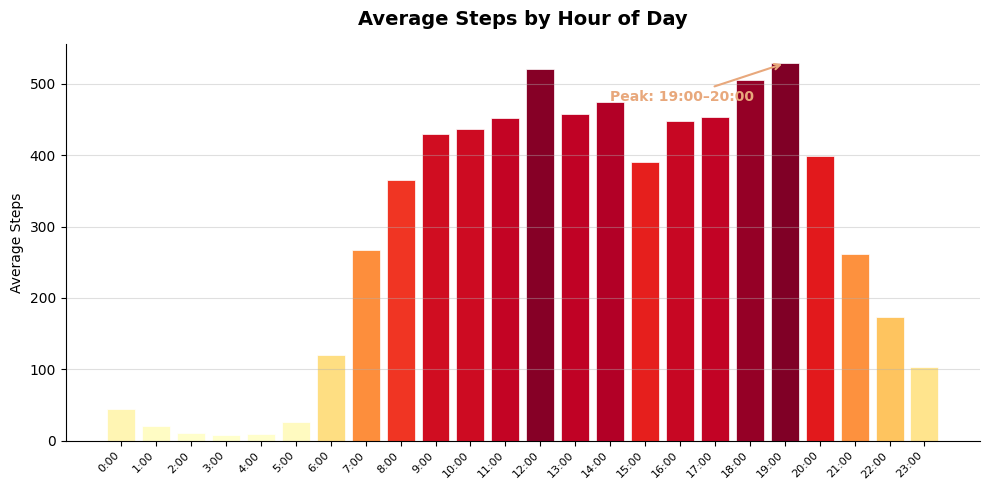

Chart 3 saved.


In [18]:
#Average Steps by Hour of Day
fig, ax = plt.subplots(figsize=(10, 5))

hourly_avg = hourly_steps.groupby('Hour')['StepTotal'].mean()
hours = list(range(24))
vals = [hourly_avg.get(h, 0) for h in hours]

# Color bars by intensity
norm = plt.Normalize(min(vals), max(vals))
bar_colors = plt.cm.YlOrRd(norm(vals))

ax.bar(hours, vals, color=bar_colors, edgecolor='white', linewidth=0.5)

# Annotate peak
peak_h = int(hourly_avg.idxmax())
ax.annotate(f'Peak: {peak_h}:00–{peak_h+1}:00',
            xy=(peak_h, hourly_avg.max()),
            xytext=(peak_h - 5, hourly_avg.max() * 0.9),
            arrowprops=dict(arrowstyle='->', color='#E8A87C', lw=1.5),
            fontsize=10, color='#E8A87C', fontweight='bold')

ax.set_xticks(hours)
ax.set_xticklabels([f'{h}:00' for h in hours], rotation=45, ha='right', fontsize=8)
ax.set_title('Average Steps by Hour of Day', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Average Steps')
ax.grid(axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_hourly_steps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

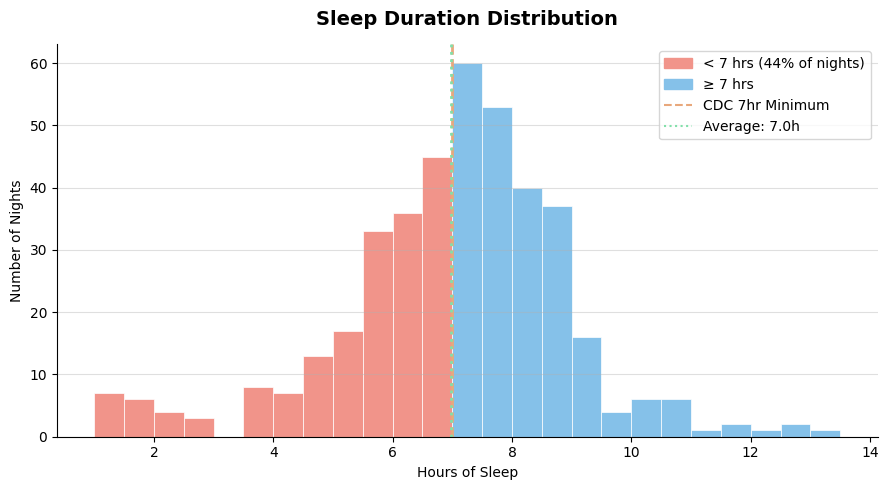

Chart 4 saved.


In [19]:
#Sleep Duration Distribution
fig, ax = plt.subplots(figsize=(9, 5))

bins = [i * 0.5 for i in range(2, 28)]  # 0.5hr bins from 1 to 14hrs
n, edges, patches = ax.hist(sleep['SleepHours'], bins=bins, edgecolor='white', linewidth=0.5)

# Color bars red if below 7 hours
for patch, left_edge in zip(patches, edges):
    patch.set_facecolor('#F1948A' if left_edge < 7 else '#85C1E9')

# Reference lines
ax.axvline(7, color='#E8A87C', linestyle='--', linewidth=2, label='7hr Minimum (CDC)')
ax.axvline(sleep['SleepHours'].mean(), color='#82E0AA', linestyle=':', linewidth=2,
           label=f"Average: {sleep['SleepHours'].mean():.1f}h")

ax.set_xlabel('Hours of Sleep')
ax.set_ylabel('Number of Nights')
ax.set_title('Sleep Duration Distribution', fontsize=14, fontweight='bold', pad=14)

legend_handles = [
    mpatches.Patch(color='#F1948A', label=f'< 7 hrs ({(sleep["SleepHours"] < 7).mean()*100:.0f}% of nights)'),
    mpatches.Patch(color='#85C1E9', label='≥ 7 hrs'),
    plt.Line2D([0], [0], color='#E8A87C', linestyle='--', label='CDC 7hr Minimum'),
    plt.Line2D([0], [0], color='#82E0AA', linestyle=':', label=f"Average: {sleep['SleepHours'].mean():.1f}h"),
]
ax.legend(handles=legend_handles)
ax.grid(axis='y', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_sleep_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

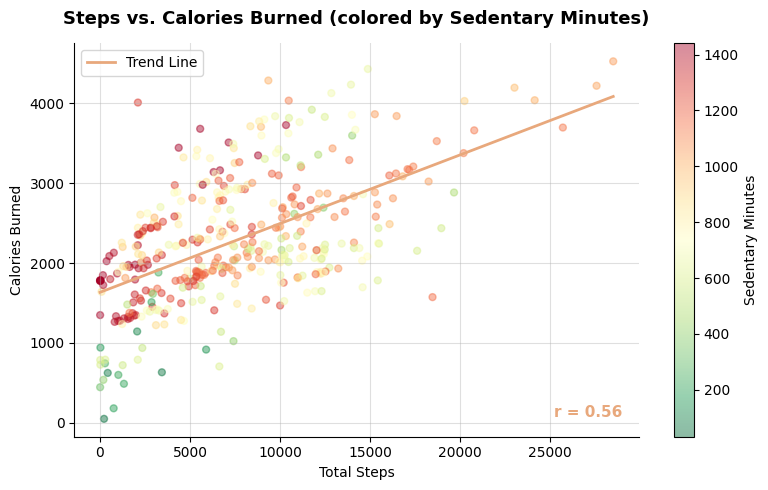

Chart 5 saved.


In [20]:
#Steps vs. Calories Burned
fig, ax = plt.subplots(figsize=(8, 5))

# Filter out zero-step, zero-calorie rows (likely non-wear days)
mask = (daily['TotalSteps'] > 0) & (daily['Calories'] > 0)
d = daily[mask]

sc = ax.scatter(d['TotalSteps'], d['Calories'],
                alpha=0.45, s=25,
                c=d['SedentaryMinutes'], cmap='RdYlGn_r')

# Trend line
m, b = np.polyfit(d['TotalSteps'], d['Calories'], 1)
x_range = np.linspace(d['TotalSteps'].min(), d['TotalSteps'].max(), 200)
ax.plot(x_range, m * x_range + b, color='#E8A87C', linewidth=2, label='Trend Line')

# Colorbar
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Sedentary Minutes')

corr = d['TotalSteps'].corr(d['Calories'])
ax.text(0.97, 0.05, f'r = {corr:.2f}', transform=ax.transAxes,
        ha='right', fontsize=11, color='#E8A87C', fontweight='bold')

ax.set_xlabel('Total Steps')
ax.set_ylabel('Calories Burned')
ax.set_title('Steps vs. Calories Burned (colored by Sedentary Minutes)',
             fontsize=13, fontweight='bold', pad=14)
ax.legend()
ax.grid(alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_steps_vs_calories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

### Key Findings Summary

| # | Finding | Stat |
|---|---|---|
| 1 | Users average well below the 10k step goal | 7,638 avg steps/day |
| 2 | Most days are spent sedentary | 16.5 avg sedentary hours/day |
| 3 | Peak activity occurs at lunch and after work | Highest steps at 6pm |
| 4 | Nearly half of users don't get enough sleep | 44% of nights < 7 hours |
| 5 | Steps and calorie burn are positively related | r = 0.59 |
| 6 | Most users engage consistently with their device | 88% tracked 25+ days |

---

### Recommendations for Bellabeat Marketing Strategy

**Recommendation 1 — Target the Step Gap with Daily Goal Campaigns**

The average user only achieves 7,638 steps per day — 23% below the widely-cited 10,000-step goal. Bellabeat can market the **Leaf tracker** and app as a daily accountability partner. Push notification reminders timed around the **5pm–7pm activity peak** (when users are already most active) could drive extra steps and reinforce positive habits. Campaigns on Instagram and TikTok should emphasize "close your rings" style messaging.

---

**Recommendation 2 — Market Bellabeat as a Sleep Wellness Tool**

With 44% of nights falling below 7 hours and users spending an average of 39 minutes lying awake in bed, sleep is a clear pain point. Bellabeat should highlight sleep tracking and the **Bellabeat Membership's** personalized sleep coaching in its marketing. Content targeting women's sleep health — especially around stress, hormones, and recovery — could perform well on Pinterest and YouTube.

---

**Recommendation 3 — Address Sedentary Behavior with Inactivity Alerts**

Users are sedentary for an average of 16.5 hours per day, and 97% of days exceed 8 hours of sedentary time. Bellabeat can differentiate by marketing smart **inactivity reminders** and hourly movement prompts. Messaging targeted at working women (desk job audience) timed around lunchtime could drive both app downloads and Leaf purchases.

---

### Next Steps
- Obtain a larger, more recent dataset to validate these findings
- Supplement with Bellabeat's own customer data if available
- Consider A/B testing notification timing strategies based on the peak activity windows identified
- Explore segmentation by user engagement level to tailor messaging